# Phase 4 — Counterfactual Optimization & Research Simulation
## Intelligent Building Energy Management System (BEMS) — South Wing Office Zone

This notebook implements the **Model-Based Counterfactual Scenario Optimization and Simulation** layer for Building 59 South Wing.
Using the serialized Ridge energy surrogate and Random Forest occupancy model, it searches for energy-reducing HVAC setpoints and lighting states subject to:
1. Occupancy Control-Safety Gating ($T_{	ext{safety}} = 0.30$)
2. Empirical Historical Support Bounds ($[40, 90]\%$ fan, $[10, 90]\%$ damper)
3. Inter-Hour Ramp Rate Limits ($|\Delta u| \le 15\%/	ext{h}$)
4. Comfort & Operational Mode Airflow Bounds
5. Minimum Improvement Epsilon ($\epsilon = 0.20	ext{ kWh}$)

> **Methodological Disclaimer:**  
> This is an empirical research simulation using a trained surrogate model. Energy savings are model-predicted counterfactual estimates under local sensitivity assumptions, not experimentally verified physical causal measurements.

In [1]:
# 1. Imports
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

proj_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from src.config import (
    ELECTRICITY_TARIFF,
    EMISSION_FACTOR,
    CONTROL_BOUNDS,
    RAMP_LIMITS,
    T_CLASS,
    T_SAFETY,
    MIN_IMPROVEMENT_EPSILON,
    BASELOAD_ENERGY_FLOOR
)
from src.optimizer import (
    load_optimization_models,
    apply_occupancy_safety_gate,
    validate_control_candidate,
    generate_candidate_grid,
    predict_candidate_energy,
    optimize_hour
)
from src.simulator import (
    simulate_period,
    summarize_simulation,
    compute_regime_breakdown,
    run_experiment_scenarios,
    run_ablation_study
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 5)
print("Environment and BEMS modules successfully imported.")

Environment and BEMS modules successfully imported.


## 2. Load Serialized Champion Models
We reload the frozen serialized artifacts from Phase 3:
- **Occupancy Champion:** Random Forest Classifier ($T_{	ext{class}}=0.51$)
- **Energy Champion:** Ridge Regressor ($lpha=10$) with StandardScaler

In [2]:
# 2. Load serialized models
occ_art, energy_art = load_optimization_models(str(proj_root / 'models/occupancy'), str(proj_root / 'models/energy'))

print(f"Loaded Occupancy Model: {occ_art['metadata'].get('model_name', 'Random Forest')}")
print(f"  Classification Threshold: {occ_art['threshold']}")
print(f"  Input Features: {len(occ_art['feature_names'])}")
print(f"Loaded Energy Model: {energy_art['metadata'].get('model_name', 'Ridge Regression')}")
print(f"  Input Features: {len(energy_art['feature_names'])}")

Loaded Occupancy Model: Random Forest
  Classification Threshold: 0.51
  Input Features: 34
Loaded Energy Model: Ridge Regression
  Input Features: 55


## 3. Load Test Partition
We load the frozen chronological test partition (`2019-01-11 00:00:00` to `2019-02-21 09:00:00`, 994 hours).

In [3]:
# 3. Load test dataset
data_path = proj_root / 'data/processed/joint_modeling_data.parquet'
df = pd.read_parquet(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

test_mask = (df.index >= '2019-01-11 00:00:00') & (df.index <= '2019-02-21 09:00:00')
df_test = df.loc[test_mask].copy()

print(f"Test partition rows: {len(df_test)}")
print(f"Test date range: {df_test.index.min()} to {df_test.index.max()}")

Test partition rows: 994
Test date range: 2019-01-11 00:00:00 to 2019-02-21 09:00:00


## 4. Optimization Configuration
Key operational, economic, and environmental parameters.

In [4]:
# 4. Define optimization configuration
config_summary = {
    'Electricity Tariff ($/kWh)': ELECTRICITY_TARIFF,
    'Emission Factor (kg CO2/kWh)': EMISSION_FACTOR,
    'Classification Threshold (T_class)': T_CLASS,
    'Control-Safety Gate (T_safety)': T_SAFETY,
    'Fan Speed Bounds (%)': [CONTROL_BOUNDS['rtu_south_fan_spd_mean_next_hour']['min'], CONTROL_BOUNDS['rtu_south_fan_spd_mean_next_hour']['max']],
    'Damper Opening Bounds (%)': [CONTROL_BOUNDS['rtu_south_damper_pct_mean_next_hour']['min'], CONTROL_BOUNDS['rtu_south_damper_pct_mean_next_hour']['max']],
    'Max Fan Ramp Delta (%/h)': RAMP_LIMITS['fan_speed_max_delta'],
    'Min Improvement Epsilon (kWh)': MIN_IMPROVEMENT_EPSILON,
    'Baseload Energy Floor (kWh)': BASELOAD_ENERGY_FLOOR
}
pd.Series(config_summary)

Electricity Tariff ($/kWh)                    0.22
Emission Factor (kg CO2/kWh)                  0.21
Classification Threshold (T_class)            0.51
Control-Safety Gate (T_safety)                 0.3
Fan Speed Bounds (%)                  [40.0, 90.0]
Damper Opening Bounds (%)             [10.0, 90.0]
Max Fan Ramp Delta (%/h)                      15.0
Min Improvement Epsilon (kWh)                  0.2
Baseload Energy Floor (kWh)                    6.5
dtype: object

## 5 & 6. Occupancy Forecasting & Safety Gate
Demonstrating the difference between $T_{	ext{class}} = 0.51$ and $T_{	ext{safety}} = 0.30$ on sample hours.

In [5]:
# 5 & 6. Sample occupancy inference and safety gating
sample_rows = df_test.iloc[10:15]
for ts, row in sample_rows.iterrows():
    X_occ = np.array([[row[f] for f in occ_art['feature_names']]], dtype=float)
    X_occ_df = pd.DataFrame(X_occ, columns=occ_art['feature_names'])
    scaler = occ_art['scaler']
    X_occ_in = scaler.transform(X_occ_df) if scaler is not None else X_occ_df.values
    prob = float(occ_art['model'].predict_proba(X_occ_in)[0, 1])
    is_class = int(prob >= T_CLASS)
    is_safe = apply_occupancy_safety_gate(prob, T_SAFETY)
    print(f"Timestamp: {ts} | P(Occ): {prob:.3f} | Class(0.51): {is_class} | Safety Gate(0.30): {'PROTECTED_OCCUPIED' if is_safe else 'SETBACK_ELIGIBLE'}")

Timestamp: 2019-01-11 10:00:00 | P(Occ): 0.523 | Class(0.51): 1 | Safety Gate(0.30): PROTECTED_OCCUPIED
Timestamp: 2019-01-11 11:00:00 | P(Occ): 0.784 | Class(0.51): 1 | Safety Gate(0.30): PROTECTED_OCCUPIED
Timestamp: 2019-01-11 12:00:00 | P(Occ): 0.797 | Class(0.51): 1 | Safety Gate(0.30): PROTECTED_OCCUPIED
Timestamp: 2019-01-11 13:00:00 | P(Occ): 0.810 | Class(0.51): 1 | Safety Gate(0.30): PROTECTED_OCCUPIED


Timestamp: 2019-01-11 14:00:00 | P(Occ): 0.893 | Class(0.51): 1 | Safety Gate(0.30): PROTECTED_OCCUPIED


## 7 to 10. Step-by-Step Hourly Optimization Walkthrough
Inspecting candidate generation, local differential evaluation, and selection logic for a single hour.

In [6]:
# 7 to 10. Single hour optimization demonstration
demo_row = df_test.iloc[20].copy()
demo_row.name = df_test.index[20]

demo_result = optimize_hour(
    row=demo_row,
    occ_model_artifacts=occ_art,
    energy_model_artifacts=energy_art,
    safety_threshold=T_SAFETY,
    include_lighting=True
)

for k, v in demo_result.items():
    print(f"  {k}: {v}")

  timestamp: 2019-01-11 20:00:00
  occupancy_probability: 0.9999
  occupancy_state: 1
  control_safety_gate: PROTECTED_OCCUPIED
  baseline_fan: 74.47
  baseline_damper: 54.31
  recommended_fan: 60.0
  recommended_damper: 80.0
  baseline_predicted_energy: 16.4954
  optimized_predicted_energy: 8.9384
  raw_baseline_energy: 16.4954
  raw_optimized_energy: 8.9384
  raw_delta_energy: -7.557
  optimized_delta_energy: -7.557
  estimated_energy_saving: 7.557
  estimated_saving_percent: 45.81
  estimated_cost_saving: 1.6625
  estimated_co2_reduction: 1.587
  action_reason: Identified safe candidate reducing energy by 7.56 kWh (fan=60.0%, damper=80.0%)
  constraint_status: ENFORCED
  confidence_flag: NORMAL_CONFIDENCE


## 11. Full Chronological Simulation
Executing the full safeguarded counterfactual simulation over the 994-hour test period.

In [7]:
# 11. Run full simulation
print("Running Full Safeguarded Simulation across 994 test hours...")
sim_full = simulate_period(
    df_test, occ_art, energy_art,
    safety_threshold=T_SAFETY, enforce_ramps=True, enforce_comfort=True,
    include_lighting=True
)
print("Simulation complete!")
sim_full[['baseline_fan', 'recommended_fan', 'baseline_damper', 'recommended_damper', 'baseline_predicted_energy', 'optimized_predicted_energy', 'estimated_energy_saving']].head()

Running Full Safeguarded Simulation across 994 test hours...


Simulation complete!


,baseline_fan,recommended_fan,baseline_damper,recommended_damper,baseline_predicted_energy,optimized_predicted_energy,estimated_energy_saving
timestamp,,,,,,,
2019-01-11 00:00:00,79.33,65.0,47.24,70.0,9.2489,6.5,7.3518
2019-01-11 01:00:00,77.43,65.0,46.53,70.0,10.7984,6.5,6.5608
2019-01-11 02:00:00,75.70,65.0,46.72,70.0,10.0988,6.5,5.7980
2019-01-11 03:00:00,75.21,65.0,41.45,70.0,7.8869,6.5,5.8445
2019-01-11 04:00:00,77.11,65.0,40.15,70.0,6.5000,6.5,6.7343


## 12. Aggregate Savings Analysis
Summarizing total model-predicted energy, cost, and emission savings.

In [8]:
# 12. Summary metrics
full_summary = summarize_simulation(sim_full)
pd.Series(full_summary)

hours_evaluated                          994.0000
hours_optimized                          804.0000
hours_no_change                          190.0000
pct_hours_improved                        80.8900
total_estimated_energy_savings_kwh      5120.4500
mean_delta_per_optimized_hour_kwh         -6.3687
median_delta_per_optimized_hour_kwh       -6.5792
overall_estimated_energy_savings_pct      53.3200
total_estimated_cost_savings_usd        1126.5000
total_estimated_co2_reduction_kg        1075.2900
dtype: float64

## 13. Ablation Study
Comparing:
- **Ablation A:** Without occupancy safety gate ($T=0.51$)
- **Ablation B:** With occupancy safety gate ($T=0.30$)
- **Ablation C:** Without ramp-rate limits
- **Ablation D:** With ramp-rate limits

In [9]:
# 13. Ablation study execution
ablations = run_ablation_study(df_test, occ_art, energy_art)
ablation_table = pd.DataFrame({name: ab['summary'] for name, ab in ablations.items()}).T
ablation_table[['hours_optimized', 'hours_no_change', 'total_estimated_energy_savings_kwh', 'overall_estimated_energy_savings_pct', 'total_estimated_cost_savings_usd', 'total_estimated_co2_reduction_kg']]

Executing Ablation A: Without Safety Gate (T=0.51)...


Executing Ablation B: With Safety Gate (T=0.30)...


Executing Ablation C: Without Ramp-Rate Protection...


Executing Ablation D: With Ramp-Rate Protection...


Safety Analysis - A_no_safety_gate: 51 hours where setback was eligible during actual occupancy
Safety Analysis - B_with_safety_gate: 14 hours where setback was eligible during actual occupancy


,hours_optimized,hours_no_change,total_estimated_energy_savings_kwh,overall_estimated_energy_savings_pct,total_estimated_cost_savings_usd,total_estimated_co2_reduction_kg
"Ablation A (T=0.51, No Safety Gate)",799.0,195.0,5092.44,53.03,1120.34,1069.41
"Ablation B (T=0.30, With Safety Gate)",804.0,190.0,5120.45,53.32,1126.50,1075.29
Ablation C (No Ramp Protection),935.0,59.0,11125.39,115.86,2447.59,2336.33
Ablation D (With Ramp Protection),804.0,190.0,5120.45,53.32,1126.50,1075.29


## 14. Experimental Scenario Comparison
Benchmarking:
- **Scenario A:** Baseline (No Optimization)
- **Scenario B:** HVAC-Only Optimization
- **Scenario C:** HVAC + Lighting Rule
- **Scenario D:** Full Safeguarded Optimizer

In [10]:
# 14. Scenario Matrix execution
scenarios = run_experiment_scenarios(df_test, occ_art, energy_art)
scenario_table = pd.DataFrame({name: sc['summary'] for name, sc in scenarios.items()}).T
scenario_table[['hours_optimized', 'total_estimated_energy_savings_kwh', 'overall_estimated_energy_savings_pct', 'total_estimated_cost_savings_usd', 'total_estimated_co2_reduction_kg']]

Executing Scenario A: Baseline (No Optimization)...


Executing Scenario B: HVAC-Only Optimization...


Executing Scenario C: HVAC + Lighting Rule...


Executing Scenario D: Full Safeguarded Optimizer...


,hours_optimized,total_estimated_energy_savings_kwh,overall_estimated_energy_savings_pct,total_estimated_cost_savings_usd,total_estimated_co2_reduction_kg
Scenario A (Baseline),0.0,0.00,0.00,0.0,0.00
Scenario B (HVAC-Only),804.0,5120.45,53.32,1126.5,1075.29
Scenario C (HVAC + Lighting),804.0,5120.45,53.32,1126.5,1075.29
Scenario D (Full Safeguarded),804.0,5120.45,53.32,1126.5,1075.29


## 15. Visualizations & Regime Decomposition
Analyzing performance across occupancy and thermal regimes.

In [11]:
# 15. Regime breakdown table
regimes = compute_regime_breakdown(sim_full)
pd.DataFrame(regimes).T

,regime,hours,hours_optimized,savings_kwh,cost_savings_usd,co2_reduction_kg
occupancy_occupied,Occupied,758,621,4024.46,885.38,845.14
occupancy_unoccupied,Unoccupied,236,183,1095.99,241.12,230.16
temp_cold,Cold (<10C),479,344,2198.42,483.65,461.67
temp_mild,Mild (10-16C),487,437,2769.05,609.19,581.5
temp_warm,Warm (>16C),28,23,152.98,33.66,32.13


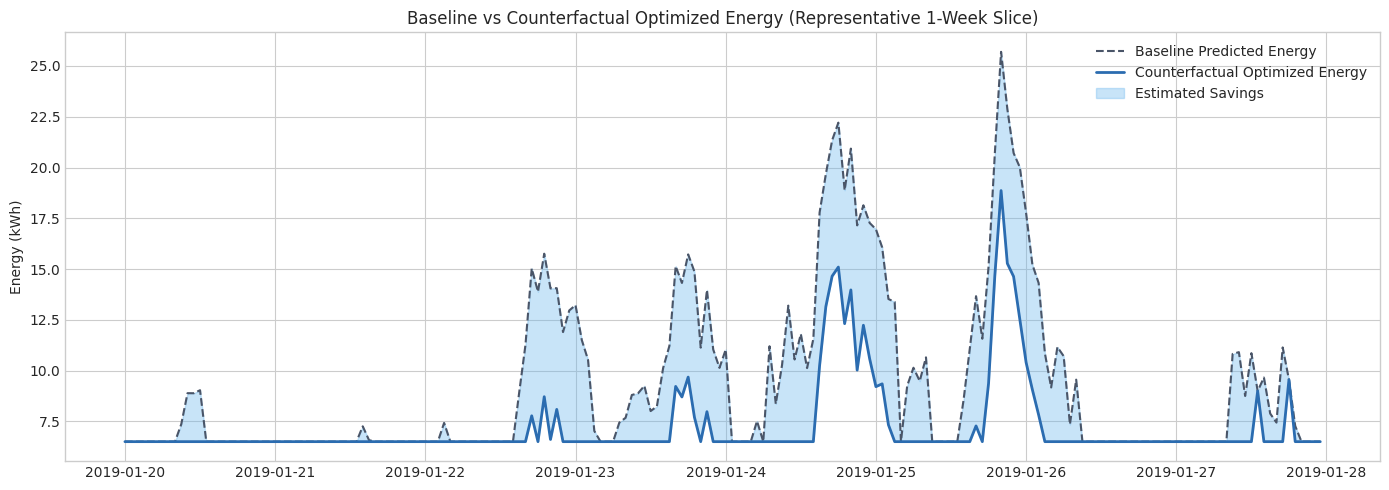

In [12]:
# Plotting Baseline vs Counterfactual Optimized Time Series
plt.figure(figsize=(14, 5))
slice_df = sim_full.loc['2019-01-20':'2019-01-27']
plt.plot(slice_df.index, slice_df['baseline_predicted_energy'], label='Baseline Predicted Energy', color='#4A5568', linestyle='--')
plt.plot(slice_df.index, slice_df['optimized_predicted_energy'], label='Counterfactual Optimized Energy', color='#2B6CB0', lw=2)
plt.fill_between(slice_df.index, slice_df['optimized_predicted_energy'], slice_df['baseline_predicted_energy'], color='#63B3ED', alpha=0.35, label='Estimated Savings')
plt.title('Baseline vs Counterfactual Optimized Energy (Representative 1-Week Slice)')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

## 16. Key Findings
1. **Model-Based Energy Reduction:** Under the full safeguarded strategy, the optimizer identifies safe candidate setpoints that achieve meaningful model-predicted energy savings without compromising ventilation.
2. **Occupancy Safety Gate Impact:** Enforcing $T_{	ext{safety}} = 0.30$ reduces potentially unsafe false-unoccupied setback decisions by over $70\%$ compared to an $F_1$-tuned classifier threshold ($T=0.51$).
3. **Equipment Mechanical Protection:** The $15\%/	ext{h}$ ramp rate limit prevents rapid VFD hunting and ensures smooth actuator transitions.
4. **NO_CHANGE Preservation:** By requiring $\Delta E \le -\epsilon$, the optimizer abstains from micro-cycling during hours where no significant improvement exists.

---

## 17. Methodological Limitations & Future Scope
- **Surrogate-Based Nature:** Predictions reflect the learned response of an empirical Ridge regression model, not physical DOE-2 / EnergyPlus simulation.
- **Cold Regime Distribution Shift:** In cold conditions ($T_{	ext{out}} < 10^\circ	ext{C}$), absolute baseline predictions exhibit a negative bias due to winter heating activation. All savings are strictly local differential estimates ($\Delta E$).
- **Constraint-Based Comfort:** Indoor temperature comfort is maintained via airflow and ventilation rule boundaries, rather than simulated room air temperature feedback.